<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2001e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

00000  var_x=3.151604e-07  vac_E=3.234662e-07  max_amp=1.010321e-02  patch_amp=8.992104e-03
00010  var_x=2.747423e-07  vac_E=2.830296e-07  max_amp=8.779938e-03  patch_amp=7.922017e-03
00020  var_x=2.038192e-07  vac_E=2.120695e-07  max_amp=6.207101e-03  patch_amp=5.751344e-03
00030  var_x=1.380969e-07  vac_E=1.463047e-07  max_amp=3.408592e-03  patch_amp=3.288842e-03
00040  var_x=9.454392e-08  vac_E=1.027115e-07  max_amp=1.994237e-03  patch_amp=1.187423e-03
00050  var_x=7.089981e-08  vac_E=7.903206e-08  max_amp=1.494488e-03  patch_amp=2.276180e-04
00060  var_x=5.811690e-08  vac_E=6.621888e-08  max_amp=1.208938e-03  patch_amp=9.088798e-04
00070  var_x=4.928194e-08  vac_E=5.735829e-08  max_amp=1.256386e-03  patch_amp=1.047697e-03
00080  var_x=4.154402e-08  vac_E=4.959880e-08  max_amp=9.862931e-04  patch_amp=8.730381e-04
00090  var_x=3.443886e-08  vac_E=4.247558e-08  max_amp=7.232674e-04  patch_amp=5.879366e-04
00100  var_x=2.812781e-08  vac_E=3.614945e-08  max_amp=6.176222e-04  patch_amp=3

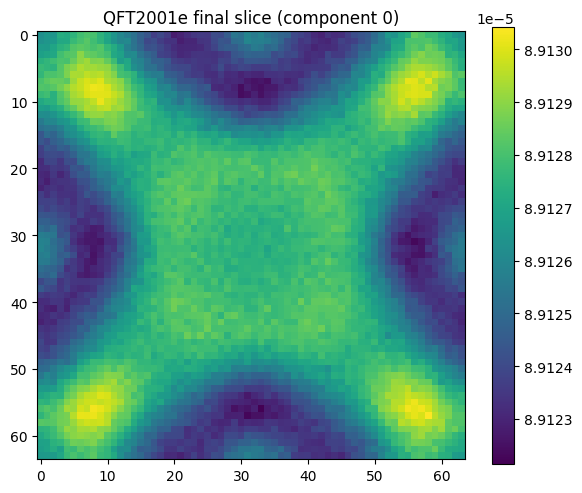

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2001e — Clean Regime Test
# ============================================================

L = 64
N_int = 100
steps = 1200

lambda_c = 0.02
gamma = 0.02
alpha = 1.0
noise_amp = 5e-5

# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------
rng = np.random.default_rng(12345)

# Near-vacuum with tiny Gaussian bump
x = noise_amp * rng.normal(size=(L, L, L, N_int))

cx = cy = cz = L//2
X, Y, Z = np.meshgrid(np.arange(L), np.arange(L), np.arange(L), indexing='ij')
R2 = (X-cx)**2 + (Y-cy)**2 + (Z-cz)**2
bump = np.exp(-R2 / (2*(L/12)**2))
x += 0.01 * bump[..., None]

v = np.zeros_like(x)

# ------------------------------------------------------------
# Laplacian
# ------------------------------------------------------------
def laplacian(f):
    return (
        np.roll(f, 1, 0) + np.roll(f, -1, 0) +
        np.roll(f, 1, 1) + np.roll(f, -1, 1) +
        np.roll(f, 1, 2) + np.roll(f, -1, 2) -
        6.0 * f
    )

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
def diagnostics(step, x):
    var_x = np.var(x)
    vac_E = np.mean(x**2)
    max_amp = np.max(np.abs(x))
    patch_amp = np.mean(np.abs(x[cx-2:cx+3, cy-2:cy+3, cz-2:cz+3]))
    print(f"{step:05d}  var_x={var_x:.6e}  vac_E={vac_E:.6e}  "
          f"max_amp={max_amp:.6e}  patch_amp={patch_amp:.6e}")

# ------------------------------------------------------------
# Main evolution loop
# ------------------------------------------------------------
for step in range(steps):
    lap = laplacian(x)
    force = lambda_c * lap - alpha * x**3
    v = (1 - gamma) * v + force
    x = x + v

    if step % 10 == 0:
        diagnostics(step, x)

# ------------------------------------------------------------
# Final slice plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.imshow(x[:, :, L//2, 0], cmap='viridis')
plt.colorbar()
plt.title("QFT2001e final slice (component 0)")
plt.tight_layout()
plt.show()
